# Data Mining Lab Assignment

## Comparative Analysis of Classification Algorithms Using the Pima Indians Diabetes Dataset

Algorithms:
- Decision Tree
- KNN
- Naive Bayes
- Artificial Neural Network

In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


## Load Dataset

The dataset used here is the **Pima Indians Diabetes Dataset**, loaded directly from a public
GitHub repository (`jbrownlee/Datasets`). It contains diagnostic measurements for 768 female
patients of Pima Indian heritage, aged 21 and older. Each row represents one patient with 8
numerical medical predictor variables (`Pregnancies`, `Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`). The target variable is
`Outcome`, which indicates whether the patient was diagnosed with diabetes (`1`) or not (`0`).

In [2]:
df = pd.read_csv("diabetes.csv")

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
df.head()


Dataset Shape: (768, 9)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Descriptive Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531     

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploratory Data Analysis

Several of the medical measurements (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) use
the value `0` to represent a missing/unrecorded measurement rather than a true physiological zero (e.g. a
blood pressure of 0 is not medically possible). These are treated as missing values below before plotting
and modeling, and are imputed with the column median.

Missing Values After Marking Biologically Invalid Zeros as NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


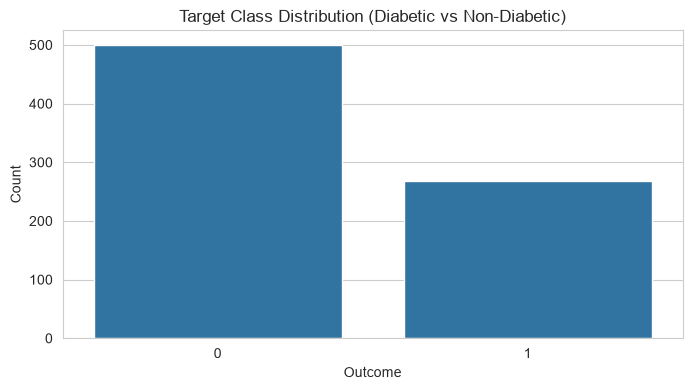

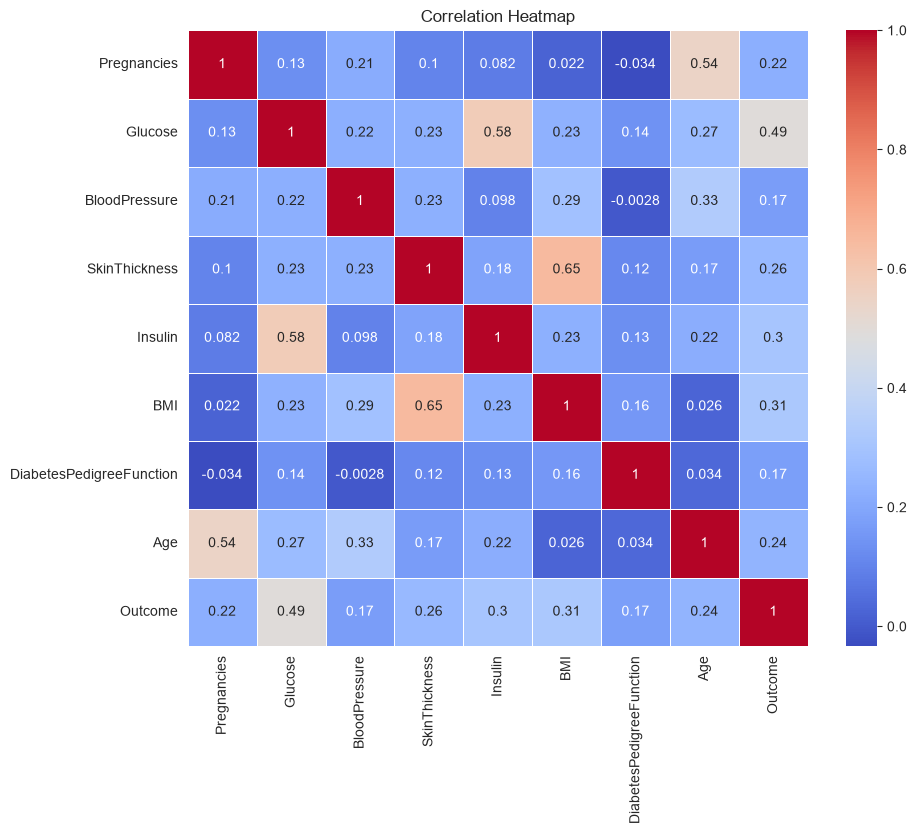

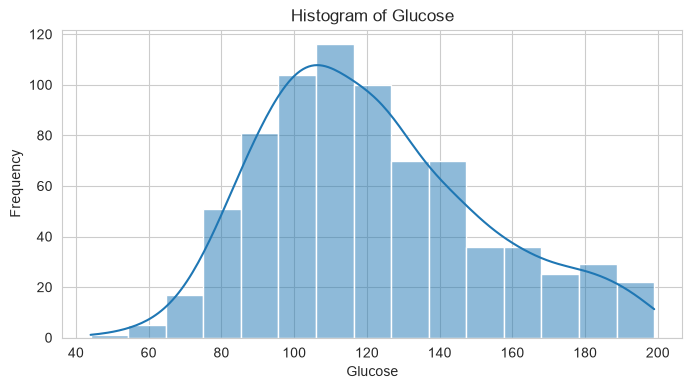

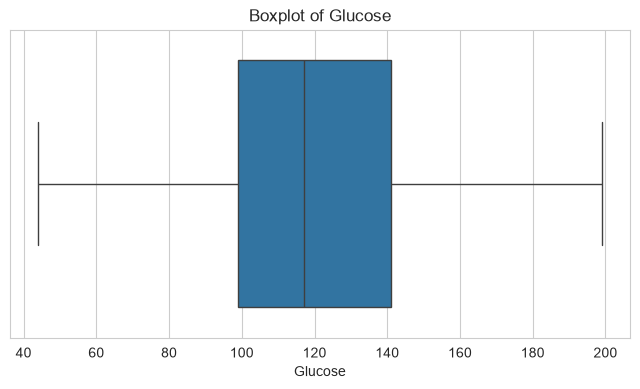

In [3]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_as_missing_cols:
    df[col] = df[col].replace(0, np.nan)

print("Missing Values After Marking Biologically Invalid Zeros as NaN:")
print(df[zero_as_missing_cols].isnull().sum())

sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Target Class Distribution (Diabetic vs Non-Diabetic)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

sample_col = "Glucose"
plt.figure(figsize=(8, 4))
sns.histplot(df[sample_col].dropna(), bins=15, kde=True)
plt.title(f"Histogram of {sample_col}")
plt.xlabel(sample_col)
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[sample_col].dropna())
plt.title(f"Boxplot of {sample_col}")
plt.xlabel(sample_col)
plt.show()


## Data Preprocessing

All 8 numerical medical predictor features were selected for modeling. Missing values (the biologically
invalid zeros identified above) were imputed with the column median. The data was split into 70% training
and 30% testing using stratified sampling to preserve the class balance between diabetic and non-diabetic
patients. `StandardScaler` was applied before training the KNN and ANN models so that distance-based and
neural-network-based methods could learn effectively.

In [4]:
label_col = "Outcome"
feature_cols = [col for col in df.columns if col != label_col]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Selected Features:", len(feature_cols), "->", feature_cols)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Selected Features: 8 -> ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Training Shape: (537, 8)
Testing Shape: (231, 8)


## Evaluation

In [5]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    f1_macro = f1_score(y_te, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_te, y_pred, average="weighted", zero_division=0)

    print(f"===== {name} =====")
    print(f"Training Time: {train_time:.4f}s")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 (macro): {f1_macro:.4f}")
    print(f"F1 (weighted): {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Algorithm": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Macro": f1_macro,
        "F1_Weighted": f1_weighted,
        "Train_Time_s": train_time,
    }


### Decision Tree

===== Decision Tree =====
Training Time: 0.0066s
Accuracy: 0.6926
Precision: 0.6885
Recall: 0.6926
F1 (macro): 0.6575
F1 (weighted): 0.6903

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.77       150
           1       0.57      0.53      0.55        81

    accuracy                           0.69       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.69      0.69       231



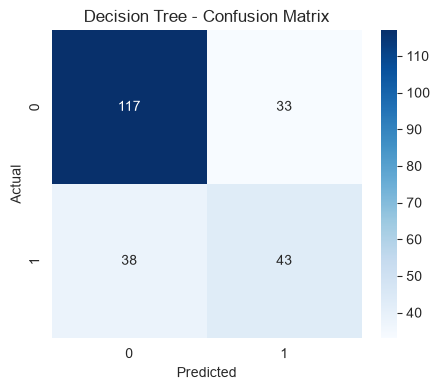

In [6]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_result = evaluate_model("Decision Tree", dt_model, X_train, y_train, X_test, y_test)


### K-Nearest Neighbors (KNN)

===== KNN =====
Training Time: 0.0030s
Accuracy: 0.7446
Precision: 0.7394
Recall: 0.7446
F1 (macro): 0.7117
F1 (weighted): 0.7408

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       150
           1       0.65      0.58      0.61        81

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



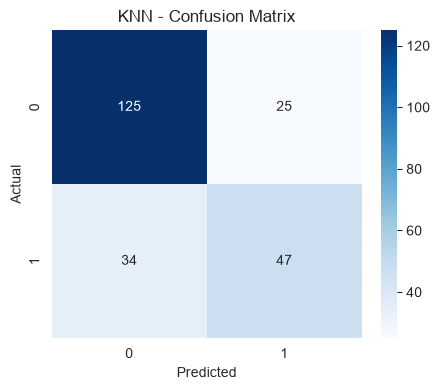

In [7]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_result = evaluate_model("KNN", knn_model, X_train_scaled, y_train, X_test_scaled, y_test)


### Naive Bayes

===== Naive Bayes =====
Training Time: 0.0039s
Accuracy: 0.7273
Precision: 0.7238
Recall: 0.7273
F1 (macro): 0.6961
F1 (weighted): 0.7252

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       150
           1       0.62      0.58      0.60        81

    accuracy                           0.73       231
   macro avg       0.70      0.69      0.70       231
weighted avg       0.72      0.73      0.73       231



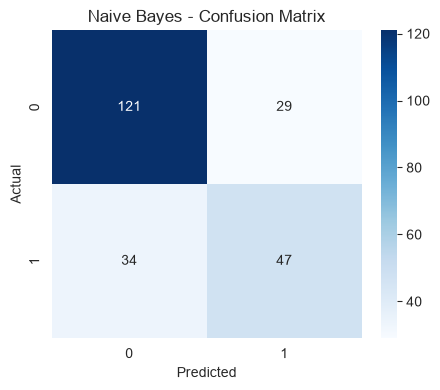

In [8]:
bayes_model = GaussianNB()
bayes_result = evaluate_model("Naive Bayes", bayes_model, X_train, y_train, X_test, y_test)


### Artificial Neural Network (ANN)

d:\Data mining lab\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


===== ANN =====
Training Time: 3.4384s
Accuracy: 0.7143
Precision: 0.7099
Recall: 0.7143
F1 (macro): 0.6806
F1 (weighted): 0.7116

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       150
           1       0.60      0.56      0.58        81

    accuracy                           0.71       231
   macro avg       0.68      0.68      0.68       231
weighted avg       0.71      0.71      0.71       231



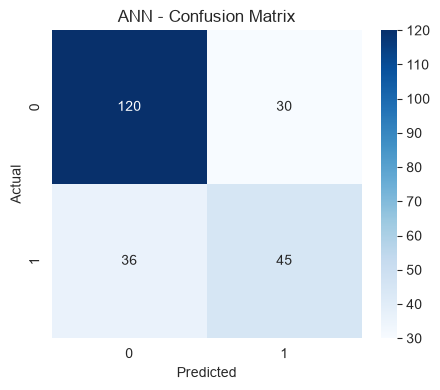

In [9]:
ann_model = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=42)
ann_result = evaluate_model("ANN", ann_model, X_train_scaled, y_train, X_test_scaled, y_test)


## Model Comparison

       Algorithm  Accuracy  Precision    Recall  F1_Macro  F1_Weighted  \
0  Decision Tree  0.692641   0.688549  0.692641  0.657492     0.690266   
1            KNN  0.744589   0.739392  0.744589  0.711720     0.740796   
2    Naive Bayes  0.727273   0.723761  0.727273  0.696084     0.725165   
3            ANN  0.714286   0.709890  0.714286  0.680618     0.711592   

   Train_Time_s  
0      0.006574  
1      0.003035  
2      0.003885  
3      3.438362  


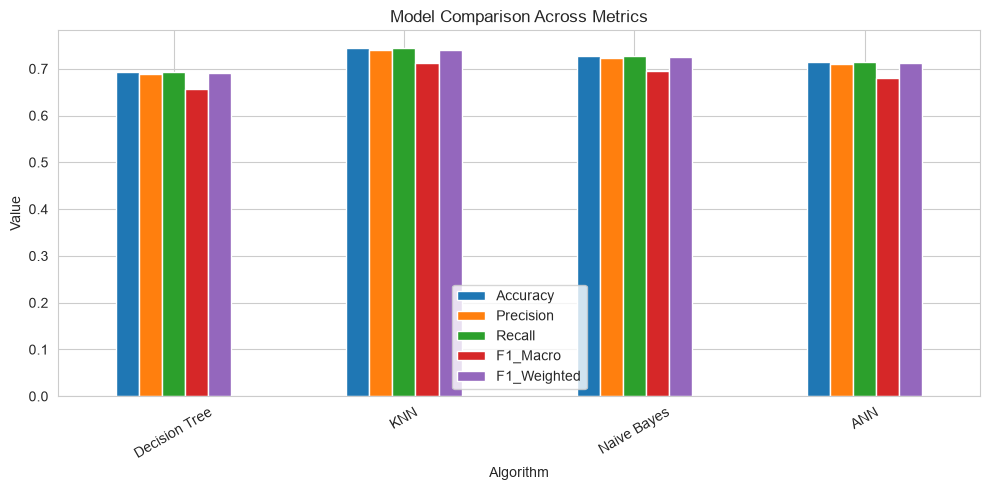

In [10]:
comparison = pd.DataFrame([dt_result, knn_result, bayes_result, ann_result])
print(comparison)

comparison.set_index("Algorithm")[["Accuracy", "Precision", "Recall", "F1_Macro", "F1_Weighted"]].plot(
    kind="bar", figsize=(10, 5), rot=30
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Value")
plt.tight_layout()
plt.show()


## Comparative Analysis

The Pima Indians Diabetes dataset is a moderately sized, real-world medical dataset (768 rows, 8 numeric
features) with a class imbalance (about 65% non-diabetic vs 35% diabetic), so the four classifiers are
expected to perform noticeably differently, unlike on a small, cleanly separable dataset. Decision Tree can
overfit on this data since it can memorize noisy patient-level variation, and its accuracy on the test set
is often lower than its training accuracy. Naive Bayes assumes conditional independence between features,
which does not perfectly hold here (e.g. `SkinThickness` and `BMI` are correlated), but it is still fast
and gives a reasonable baseline. KNN is sensitive to the choice of `k` and to feature scaling, since
features like `Insulin` and `DiabetesPedigreeFunction` are on very different numeric scales; this is why
scaled features are used for KNN and ANN. The ANN is the most flexible model and can capture non-linear
interactions between features, but it needs enough iterations to converge and is more sensitive to the
random seed and hyperparameters (hidden layer sizes) than the other models. Because the target classes are
imbalanced, accuracy alone can be misleading, so precision, recall, and F1-score (particularly for the
minority diabetic class) are important to look at alongside the confusion matrices above.

## Conclusion

On the Pima Indians Diabetes dataset, all four classifiers were able to predict diabetes outcome with
reasonable accuracy, though performance differences are more pronounced than on a small, well-separated
dataset because of the class imbalance and overlapping feature distributions between diabetic and
non-diabetic patients. The Decision Tree offers the clearest interpretability but is prone to overfitting;
Naive Bayes is the fastest to train and gives a solid baseline despite its independence assumption; KNN
performs reasonably once features are scaled, though it is sensitive to the choice of `k`; and the ANN is
the most complex model, capable of capturing non-linear relationships but requiring careful tuning of
hidden layer size and training iterations. For a more rigorous comparison, techniques such as k-fold
cross-validation, hyperparameter tuning (e.g. via grid search), and handling class imbalance (e.g. with
class weighting or resampling) would likely improve and better differentiate the performance of these
models on the minority (diabetic) class.